<a href="https://colab.research.google.com/github/diogenesjusto/FIAP/blob/master/MBAIA/14DTSR_Aula2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [138]:
# Carga bibliotecas
import pandas as pd
import sklearn.preprocessing as skpp
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

In [139]:
# Carga de dados
df = pd.read_csv("https://raw.githubusercontent.com/diogenesjusto/FIAP-On-Line-Graduation/main/datasets/%20mtcars.csv")

<Axes: xlabel='wt', ylabel='mpg'>

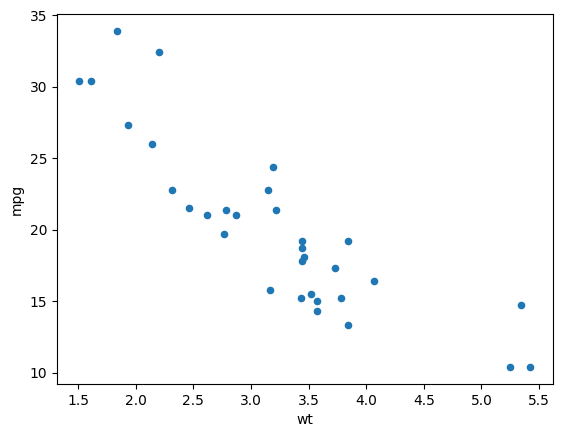

In [140]:
# Gráfico de dispersão
df.plot.scatter(x="wt", y="mpg")

In [141]:
df[['wt','mpg']].corr()

,wt,mpg
wt,1.000000,-0.867659
mpg,-0.867659,1.000000


In [142]:
# Transf. Log-Lin
df['wt_log'] = np.log(df['wt'])
df[['wt_log','mpg']].corr()

,wt_log,mpg
wt_log,1.000000,-0.900081
mpg,-0.900081,1.000000


<Axes: xlabel='wt_log', ylabel='mpg'>

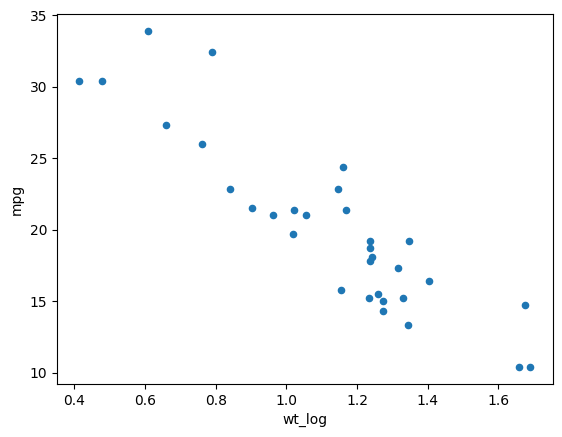

In [143]:
# Gráfico de dispersão
df.plot.scatter(x="wt_log", y="mpg")

In [144]:
# Função de transf. polinomial
poly = skpp.PolynomialFeatures(degree=11)

# Speração (split)
x_treino, x_teste, y_treino, y_teste = train_test_split(df[['wt']], df['mpg'], test_size=0.25, random_state=1)

x_treino = poly.fit_transform(x_treino)
x_teste = poly.fit_transform(x_teste)

In [145]:
# Regressão Linear
mod = LinearRegression()
mod.fit(x_treino, y_treino)

# R2
print(mod.score(x_treino, y_treino))

0.9584766175421514


In [146]:
# Previsão
y_prev = mod.predict(x_teste)

y_prev

array([356.75987571,  22.22871935,  18.21184659, 160.86177191,
        17.01113266,  25.81439779,  16.93142635,  22.82998258])

In [147]:

# Avaliação do erro de previsão
print(mean_squared_error(y_teste, y_prev))

15456.176586777723


## Redistribuição de dados

In [179]:
# Carga bibliotecas
import pandas as pd
import numpy as np

In [180]:
# Carga de dados
fv = pd.read_csv("https://raw.githubusercontent.com/diogenesjusto/FIAP/master/dados/db_Exercicio_RFM.csv")

In [181]:
fv

,Unnamed: 0,CUSTOMER_ID,STORE_ID,PRODUCT_ID,AMOUNT,DATE
0,1,95595791691,409,196282,8.98,2020-01-01 00:14:41 UTC
1,2,8814812624,62,136956,0.00,2020-01-01 00:10:16 UTC
2,3,38552620634,408,329,9.98,2020-01-01 00:08:29 UTC
3,4,11561694614,405,104089,7.99,2020-01-01 00:06:10 UTC
4,5,1216506698,62,196180,11.96,2020-01-01 00:05:30 UTC
...,...,...,...,...,...,...
92289,92290,10264569679,417,160178,2.15,2019-11-08 10:29:32 UTC
92290,92291,74199480625,405,194991,2.99,2019-11-08 10:29:22 UTC
92291,92292,60400722615,415,185621,4.30,2019-11-08 10:27:06 UTC
92292,92293,3623837660,65,193506,6.29,2019-11-08 10:16:58 UTC


In [182]:
dfAgg = fv.groupby(by=['CUSTOMER_ID'])['AMOUNT'].agg(['sum','count'])
dfAgg

,sum,count
CUSTOMER_ID,,
191,17.82,1
1202782,13.80,1
1209604,38.79,1
1480677,8.98,1
1593609,3.99,1
...,...,...
6298976531803343,12.90,1
6298976531895851,89.90,1
6298976532232294,51.78,3


<Axes: xlabel='sum', ylabel='count'>

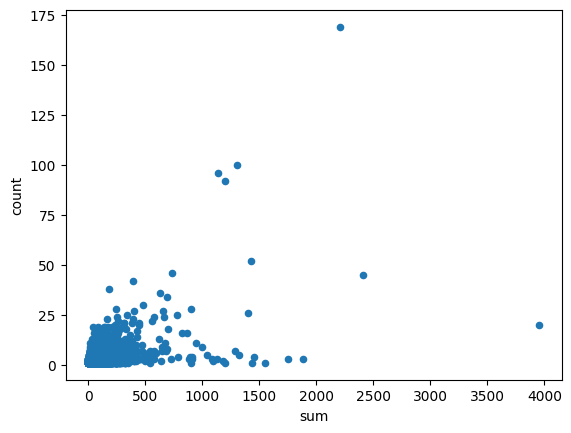

In [183]:
dfAgg.plot.scatter(x='sum', y='count')

array([[<Axes: title={'center': 'sum'}>]], dtype=object)

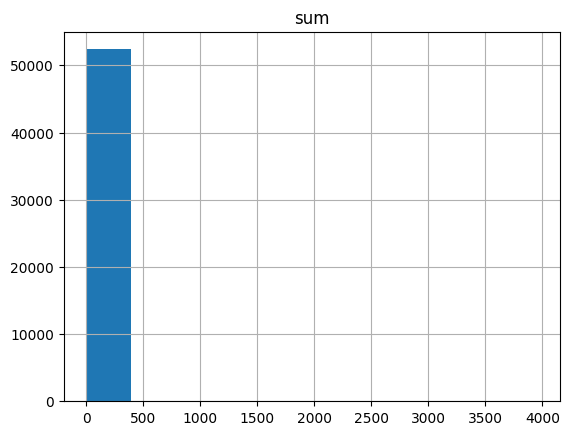

In [184]:
# Distribuição da variável V (do RFV)
dfAgg.hist('sum')

array([[<Axes: title={'center': 'count'}>]], dtype=object)

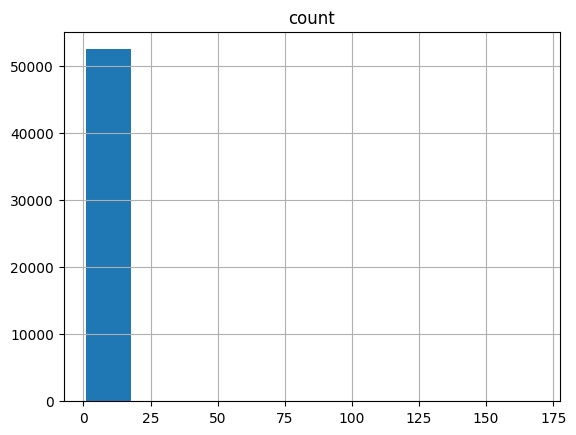

In [185]:
# Distribuição da variável F (do RFV)
dfAgg.hist('count')

In [186]:
!pip install datashader
import datashader as ds

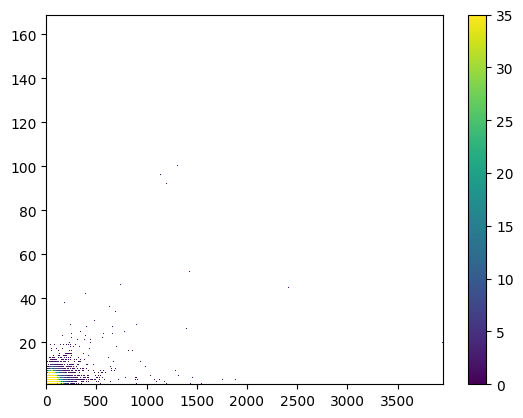

In [187]:
from datashader.mpl_ext import dsshow
import matplotlib.pyplot as plt

def using_shader(ax, x, y):
  df = pd.DataFrame(dict(x=x, y=y))
  dsa = dsshow(
      df,
      ds.Point("x", "y"),
      ds.count(),
      vmin = 0,
      vmax=35,
      norm='linear',
      aspect="auto",
      ax = ax
  )

  plt.colorbar(dsa)

fig, ax = plt.subplots()
using_shader(ax, dfAgg['sum'].values, dfAgg['count'].values)

In [188]:
x = dfAgg['sum'].values
y = dfAgg['count'].values
# Temos alguns valores 0 em amount. Decisão de aplicar um valor muito próximo a zero, para poder realizar o cálculo - log
x[x==0]=0.0001

x_log = np.log(x)
y_log = np.log(y)

dfAgg['count_log'] = y_log
dfAgg['sum_log'] = x_log

array([[<Axes: title={'center': 'count_log'}>]], dtype=object)

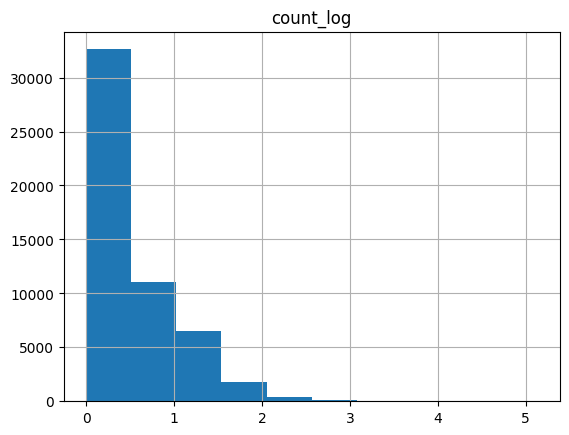

In [189]:
# Redistribuição de frequência
dfAgg.hist('count_log')

array([[<Axes: title={'center': 'sum_log'}>]], dtype=object)

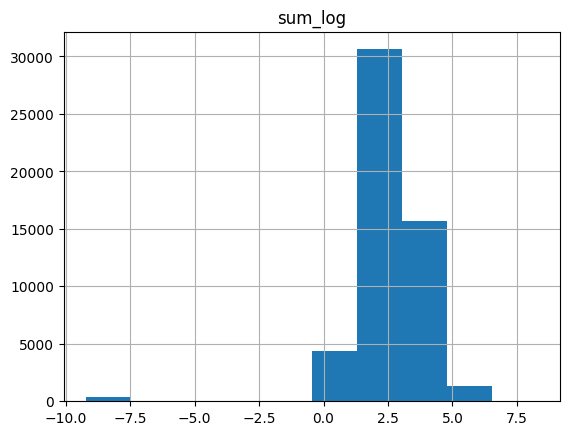

In [190]:
# Redistribuição de valor
dfAgg.hist('sum_log')